In [5]:
import pandas as pd
import glob
import os

# 1. Define the path to your folder
folder_path = '../raw_data/nepse_100'

# Find all CSV files in that folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []

print(f"Found {len(all_files)} files. Merging...")

# 2. Loop through every file
for file in all_files:
    # Read the CSV
    df = pd.read_csv(file)
    
    # Extract the symbol from the filename (e.g., 'NICA.csv' -> 'NICA')
    symbol = os.path.basename(file).split('.')[0]
    
    # Add a 'Symbol' column so we know which stock this row belongs to
    df['Symbol'] = symbol
    
    df_list.append(df)

# 3. Combine everything into one massive Master Dataset
master_df = pd.concat(df_list, ignore_index=True)

# 4. Clean up the Date column and sort it chronologically
master_df['Date'] = pd.to_datetime(master_df['Date'])
master_df = master_df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

print(f"✅ Success! Master dataset created with {len(master_df)} rows and {len(master_df.columns)} columns.")

# Display the first 5 rows to verify it worked
master_df.head()

Found 100 files. Merging...
✅ Success! Master dataset created with 201115 rows and 24 columns.


,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turnover,Daily_Return,...,EMA_26,RSI_14,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV
0,ADBL,2012-01-01,115.0,115.0,113.0,114.0,-0.87 %,1111.0,125973.0,NaN,...,114.000000,18.819188,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0
1,ADBL,2012-01-02,114.0,118.0,115.0,118.0,3.51 %,551.0,64227.0,0.035088,...,114.296296,26.214341,0.319088,0.063818,NaN,NaN,NaN,NaN,NaN,551.0
2,ADBL,2012-01-03,118.0,116.0,114.0,115.0,-2.54 %,490.0,56130.0,-0.025424,...,114.348422,27.589938,0.326134,0.116281,NaN,NaN,NaN,NaN,NaN,61.0
3,ADBL,2012-01-04,115.0,115.0,113.0,114.0,-0.87 %,3220.0,369040.0,-0.008696,...,114.322613,36.328662,0.248165,0.142658,NaN,NaN,NaN,NaN,NaN,-3159.0
4,ADBL,2012-01-05,114.0,114.0,112.0,113.0,-0.88 %,775.0,87595.0,-0.008772,...,114.224642,38.978141,0.104478,0.135022,NaN,NaN,NaN,NaN,NaN,-3934.0


In [6]:
# 1. Drop all rows that contain NaN values across our indicator columns
cleaned_df = master_df.dropna().reset_index(drop=True)

# 2. Confirm the new shape of your data matrix
print(f"📊 Original rows: {master_df.shape[0]}")
print(f"🧹 Cleaned training rows remaining: {cleaned_df.shape[0]}")
print(f"📉 Rows removed due to indicator startup delay: {master_df.shape[0] - cleaned_df.shape[0]}")

# 3. Double-check to guarantee zero NaNs remain
print(f"\nRemaining missing entries: {cleaned_df.isnull().sum().sum()}")

📊 Original rows: 201115
🧹 Cleaned training rows remaining: 197911
📉 Rows removed due to indicator startup delay: 3204

Remaining missing entries: 0


In [13]:
import numpy as np

# 1. Hunt down all positive and negative infinities and turn them into NaNs
final_df = final_df.replace([np.inf, -np.inf], np.nan)

# 2. Drop any rows that just became NaN
final_df = final_df.dropna().reset_index(drop=True)

print(f"🧹 Infinities purged! Final clean dataset shape: {final_df.shape}")

🧹 Infinities purged! Final clean dataset shape: (197809, 26)


In [14]:
# 1. Define the updated column names based on your precise dataset schema
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Turnover',
    'Daily_Return', 'Log_Return', 'SMA_5', 'SMA_20', 
    'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 
    'ATR_14', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'OBV'
]

# Extract them into X (features) and y (target) matrices
X = final_df[feature_cols]
y = final_df['Target']

# 2. Chronological Train-Test Split (80% training history, 20% validation testing)
split_index = int(len(final_df) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"📐 Training feature matrix shape: {X_train.shape}")
print(f"🧪 Testing feature matrix shape: {X_test.shape}")

📐 Training feature matrix shape: (158247, 20)
🧪 Testing feature matrix shape: (39562, 20)


In [ ]:
# 1. Create a column for 'Tomorrow's Close Price' by shifting the Close price up by 1 row within each stock group
cleaned_df['Tomorrow_Close'] = cleaned_df.groupby('Symbol')['Close'].shift(-1)

# 2. Define the Target: 1 if Tomorrow's Close is higher than Today's Close, otherwise 0
cleaned_df['Target'] = (cleaned_df['Tomorrow_Close'] > cleaned_df['Close']).astype(int)

# 3. Because the very last day for each stock won't have a 'Tomorrow', it becomes NaN. We drop those 100 rows.
final_df = cleaned_df.dropna(subset=['Tomorrow_Close']).reset_index(drop=True)

# 4. Check the balance of your dataset (How many Ups vs. Downs)
print("📊 Target Distribution (0 = Down/Flat, 1 = Up):")
print(final_df['Target'].value_counts(normalize=True))

print(f"\nFinal dataset shape ready for ML: {final_df.shape}")

In [9]:
print(list(final_df.columns))

['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change', 'Volume', 'Turnover', 'Daily_Return', 'Log_Return', 'SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'ATR_14', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'OBV', 'Tomorrow_Close', 'Target']


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Scale features so massive volumes don't distort smaller technical indicators
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize and Train the Random Forest Classifier
print("🧠 Training the Random Forest model across 197k rows (this may take a moment)...")
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# 3. Predict metrics against the out-of-sample test environment
y_pred = model.predict(X_test_scaled)

# 4. Evaluate baseline structural predictive power
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Baseline Test Accuracy: {accuracy:.4f}\n")
print("📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

🧠 Training the Random Forest model across 197k rows (this may take a moment)...

🎯 Baseline Test Accuracy: 0.5671

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.96      0.71     22211
           1       0.56      0.06      0.11     17351

    accuracy                           0.57     39562
   macro avg       0.56      0.51      0.41     39562
weighted avg       0.56      0.57      0.45     39562



Matplotlib is building the font cache; this may take a moment.


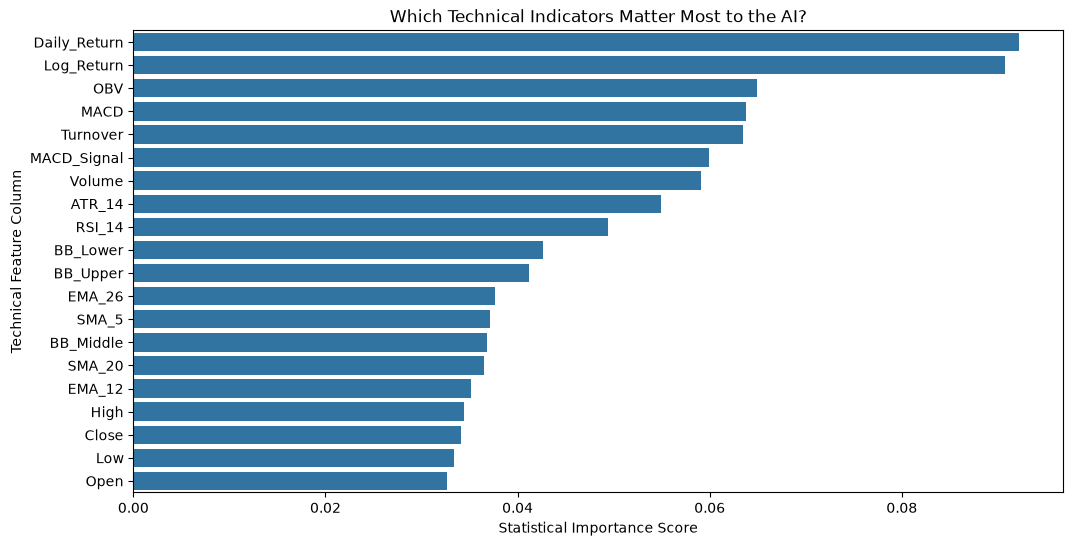

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract how much weight the AI gave to each technical indicator
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot the results visually right inside your notebook
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Which Technical Indicators Matter Most to the AI?')
plt.xlabel('Statistical Importance Score')
plt.ylabel('Technical Feature Column')
plt.show()

In [17]:
# 1. Re-train the model, but force it to balance its attention between Up and Down days
print("🧠 Re-training the model to cure the Perma-Bear flaw...")
model_balanced = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    class_weight='balanced',  # <--- THE MAGIC FIX
    n_jobs=-1
)
model_balanced.fit(X_train_scaled, y_train)

# 2. Make new predictions
y_pred_balanced = model_balanced.predict(X_test_scaled)

# 3. Evaluate the new, balanced model
accuracy_bal = accuracy_score(y_test, y_pred_balanced)
print(f"\n🎯 Balanced Test Accuracy: {accuracy_bal:.4f}\n")
print("📋 New Classification Report:")
print(classification_report(y_test, y_pred_balanced))

🧠 Re-training the model to cure the Perma-Bear flaw...

🎯 Balanced Test Accuracy: 0.5468

📋 New Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.62      0.61     22211
           1       0.48      0.45      0.47     17351

    accuracy                           0.55     39562
   macro avg       0.54      0.54      0.54     39562
weighted avg       0.54      0.55      0.54     39562



In [18]:
import joblib
import os

# 1. Create a dedicated folder in your backend to hold the AI models
os.makedirs('../models', exist_ok=True)

# 2. Save the trained Random Forest model
model_path = '../models/nepse_rf_model.joblib'
joblib.dump(model_balanced, model_path)

# 3. Save the StandardScaler 
scaler_path = '../models/nepse_scaler.joblib'
joblib.dump(scaler, scaler_path)

print("💾 Success! AI Brain and Scaler successfully exported to the backend/models/ directory.")

💾 Success! AI Brain and Scaler successfully exported to the backend/models/ directory.


In [19]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# 1. Initialize the Walk-Forward Validation engine (5 rolling splits)
tscv = TimeSeriesSplit(n_splits=5)
fold_scores = []

print("🔄 Initiating Walk-Forward Validation (Time-Series Split)...\n")

# 2. Loop through time chronologically
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    # Split the data for this specific time window
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Scale the data based ONLY on the current training window
    X_train_scaled_cv = scaler.fit_transform(X_train_cv)
    X_test_scaled_cv = scaler.transform(X_test_cv)
    
    # Train the balanced model on the growing historical data
    model_balanced.fit(X_train_scaled_cv, y_train_cv)
    
    # Predict the "future" (the test fold)
    preds = model_balanced.predict(X_test_scaled_cv)
    
    # Record the accuracy
    acc = accuracy_score(y_test_cv, preds)
    fold_scores.append(acc)
    
    print(f"✅ Fold {fold + 1} | Training Rows: {len(X_train_cv)} | Test Rows: {len(X_test_cv)} | Accuracy: {acc:.4f}")

# 3. Calculate the final, mathematically rigorous score
print(f"\n📊 Final Validated Walk-Forward Accuracy: {np.mean(fold_scores):.4f}")

🔄 Initiating Walk-Forward Validation (Time-Series Split)...

✅ Fold 1 | Training Rows: 32969 | Test Rows: 32968 | Accuracy: 0.5383
✅ Fold 2 | Training Rows: 65937 | Test Rows: 32968 | Accuracy: 0.5505
✅ Fold 3 | Training Rows: 98905 | Test Rows: 32968 | Accuracy: 0.5450
✅ Fold 4 | Training Rows: 131873 | Test Rows: 32968 | Accuracy: 0.5365
✅ Fold 5 | Training Rows: 164841 | Test Rows: 32968 | Accuracy: 0.5467

📊 Final Validated Walk-Forward Accuracy: 0.5434


In [ ]:
# Train on 100% of the historical data to maximize its intelligence
X_scaled_full = scaler.fit_transform(X)
model_balanced.fit(X_scaled_full, y)

# Overwrite the previous saves with the ultimate model
joblib.dump(model_balanced, '../models/nepse_rf_model.joblib')
joblib.dump(scaler, '../models/nepse_scaler.joblib')

print("Final Maximum-Intelligence Model saved! You can close Jupyter now.")

Final Maximum-Intelligence Model saved! You can close Jupyter now.
